In [ ]:
print("Radhe_Radhe")

Radhe_Radhe


In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Install Kaggle CLI and download dataset
!pip install -q kaggle ultralytics
!kaggle datasets download -d ankanghosh651/object-detection-wildlife-dataset-yolo-format
!unzip -q object-detection-wildlife-dataset-yolo-format.zip -d wildlife_yolo_dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.8/978.8 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.1 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/ankanghosh651/object-detection-wildlife-dataset-yolo-format
License(s): MIT


In [ ]:
import os

for root, dirs, files in os.walk('wildlife_yolo_dataset'):
    level = root.replace('wildlife_yolo_dataset', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:  # only first 3 files in each dir
        print(f"{subindent}{f}")


wildlife_yolo_dataset/
    final_data/
        data_wl.yaml
        test/
            labels/
                1091.txt
                1341.txt
                1123.txt
            images/
                1039.jpg
                0915.jpg
                0846.jpg
        train/
            labels.cache
            labels/
                1440.txt
                0676.txt
                1109.txt
            images/
                1323.jpg
                0407.jpg
                0327.jpg
        valid/
            labels.cache
            labels/
                0392.txt
                1239.txt
                0284.txt
            images/
                0341.jpg
                0100.jpg
                1338.jpg


In [ ]:
import yaml

# Load class names from your data_wl.yaml file
yaml_path = 'wildlife_yolo_dataset/final_data/data_wl.yaml'

with open(yaml_path, 'r') as f:
    yaml_data = yaml.safe_load(f)

# Extract class names from the 'names' key
class_names = yaml_data.get('names', [])
print("Class Names:", class_names)


Class Names: {0: 'buffalo', 1: 'elephant', 2: 'rhino', 3: 'zebra'}


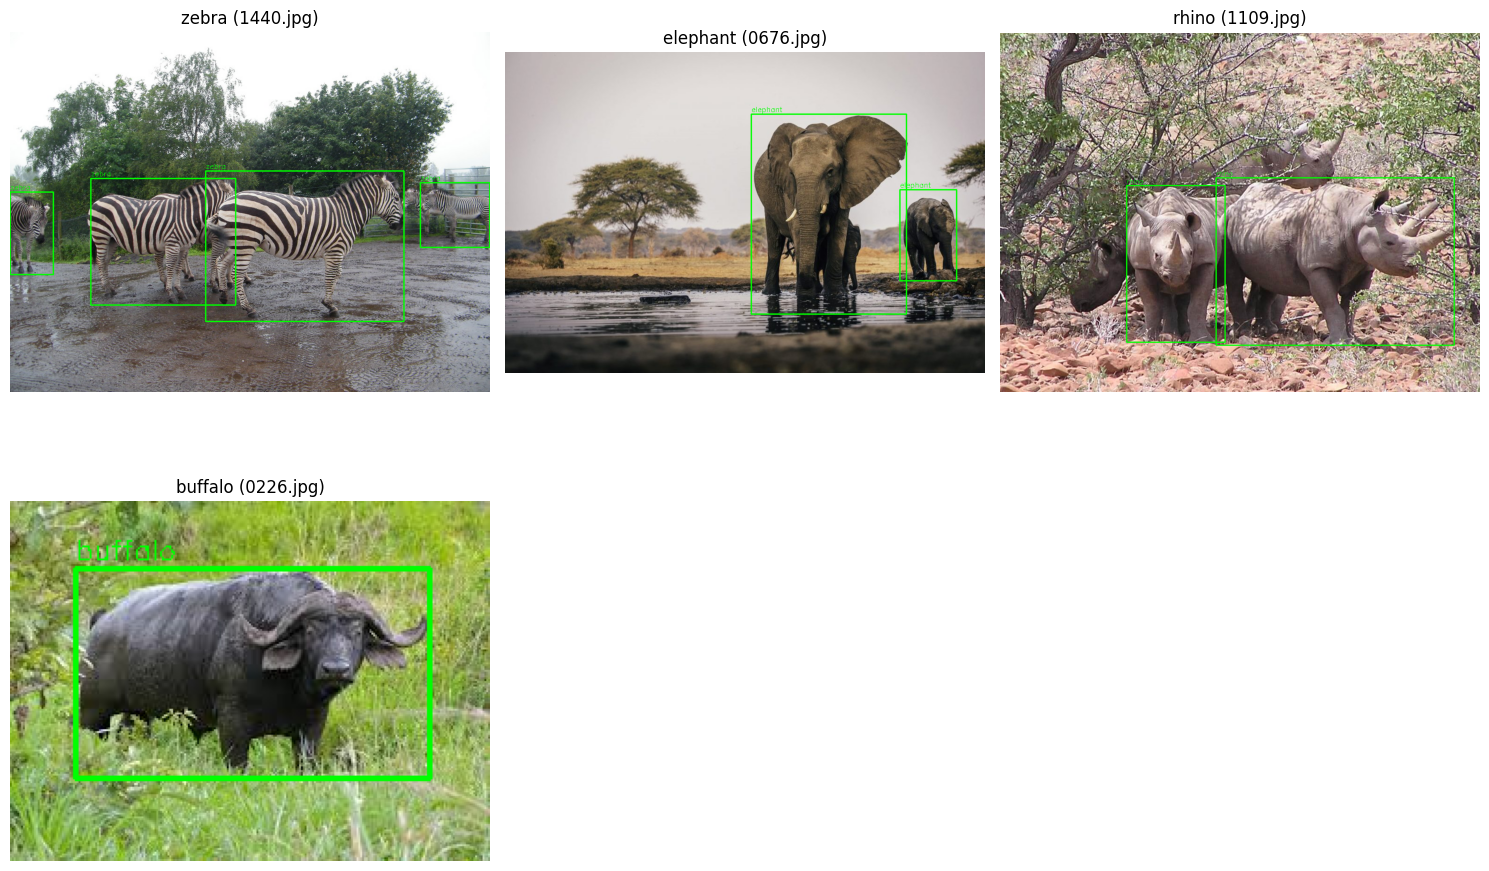

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Define the directory for labels and images
label_dir = 'wildlife_yolo_dataset/final_data/train/labels'  # Modify this path based on your dataset
img_dir = 'wildlife_yolo_dataset/final_data/train/images'    # Modify this path based on your dataset

# Convert class names from dict to list
class_names = [class_name for _, class_name in sorted(yaml_data['names'].items())]

# Function to draw bounding boxes
def draw_boxes(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    with open(label_path, 'r') as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, class_names[int(cls)], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# Display 1 image per class (you can change to 5 later)
shown_classes = set()
plt.figure(figsize=(15, 10))

i = 0
for file in os.listdir(label_dir):
    label_path = os.path.join(label_dir, file)
    with open(label_path, 'r') as f:
        lines = f.readlines()
        if not lines:
            continue
        cls = int(lines[0].split()[0])
        if cls in shown_classes:
            continue
        shown_classes.add(cls)
        img_name = file.replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_name)
        if not os.path.exists(img_path):
            continue
        img = draw_boxes(img_path, label_path, class_names)
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"{class_names[cls]} ({img_name})")
        plt.axis('off')
        i += 1
        if i == 5:
            break

plt.tight_layout()
plt.show()


In [ ]:
# YAML content for training and validation paths, classes
yaml_content = """
train: wildlife_yolo_dataset/final_data/train/images
val: wildlife_yolo_dataset/final_data/valid/images

nc: 4  # Number of classes
names: ['buffalo', 'elephant', 'rhino', 'zebra']  # Class names
"""

# Save it to the 'data_wl.yaml' file in the appropriate folder
with open('/content/wildlife_yolo_dataset/final_data/data_wl.yaml', 'w') as f:
    f.write(yaml_content)


In [ ]:
# Check if file is created
with open('/content/wildlife_yolo_dataset/final_data/data_wl.yaml', 'r') as f:
    print(f.read())



train: wildlife_yolo_dataset/final_data/train/images
val: wildlife_yolo_dataset/final_data/valid/images

nc: 4  # Number of classes
names: ['buffalo', 'elephant', 'rhino', 'zebra']  # Class names



In [ ]:
!echo -e "train: /content/wildlife_yolo_dataset/final_data/train/images\nval: /content/wildlife_yolo_dataset/final_data/valid/images\n\nnc: 4\nnames: ['buffalo', 'elephant', 'rhino', 'zebra']" > /content/wildlife_yolo_dataset/final_data/data_wl.yaml


In [ ]:
from ultralytics import YOLO

# Load YOLOv5 model (small model for training)
model = YOLO('yolov5s.yaml')  # Or use yolov5m.yaml for better accuracy

# Train the model with augmentation and learning rate scheduler
model.train(
    data='/content/wildlife_yolo_dataset/final_data/data_wl.yaml',  # Path to the data_wl.yaml
    epochs=50,  # Try 50 epochs for better results
    imgsz=640,  # Image size (640x640)
    batch=16,  # Batch size
    device=0,  # Use GPU (0) if available, otherwise use CPU
    augment=True,  # Enable augmentation
    lr0=0.01,  # Starting learning rate (default 0.01)
    lrf=0.1,  # Final learning rate (default 0.1)
    save_period=5,  # Save checkpoint after every 5 epochs
)


Ultralytics 8.3.110 🚀 Python-3.11.12 torch-2.6.0+cu124 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: 0
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
import os

# Check all folders inside /content/runs/
for root, dirs, files in os.walk("/content/runs"):
    for name in files:
        if name == "best.pt":
            print("Model path: ", os.path.join(root, name))


In [ ]:
from google.colab import files
uploaded = files.upload()



In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display

# Load trained model
model = YOLO('/content/runs/detect/train3/weights/best.pt')

# Use uploaded image file
image_path = list(uploaded.keys())[0]

# Predict
results = model(image_path)

# Show prediction image
results[0].save(filename='predicted.jpg')  # Save result
display(Image(filename='predicted.jpg'))   # Display result
